<a href="https://colab.research.google.com/github/luizaluiz/TelecomX_1/blob/main/TelecomX_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    df = pd.json_normalize(data)
    print("Extração concluída com sucesso!")
else:
    print(f"Erro na extração. Verifique a URL. Status code: {response.status_code}")
    print(f"Response text: {response.text[:500]}...")

Extração concluída com sucesso!


#📌 Extracão

In [ ]:
print("\n🔍 Tipos de dados nas colunas:")
print(df.info())

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
    print("\n✅ Coluna 'TotalCharges' convertida para numérico.")


🔍 Tipos de dados nas colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupp

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce').fillna(0)

df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

df_analise = df.drop(columns=['customerID'])

print("✅ Transformação concluída: 'Total Charges' agora é numérico!")

✅ Transformação concluída: 'Total Charges' agora é numérico!


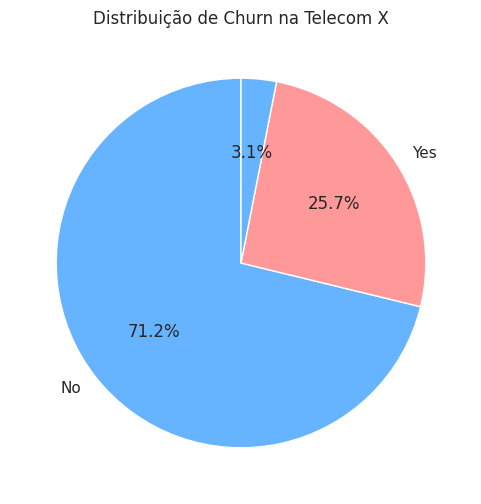

In [ ]:
plt.figure(figsize=(6, 6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Distribuição de Churn na Telecom X')
plt.ylabel('')
plt.show()

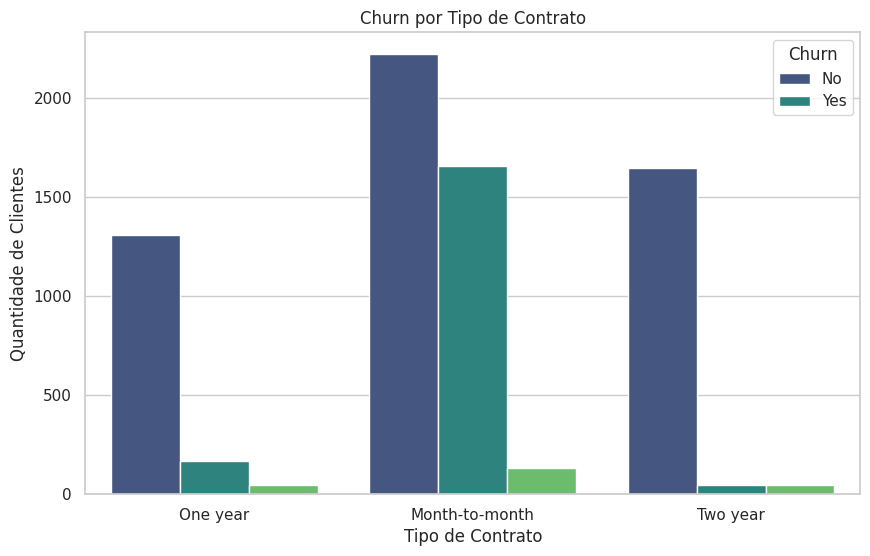

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='account.Contract', hue='Churn', palette='viridis')
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

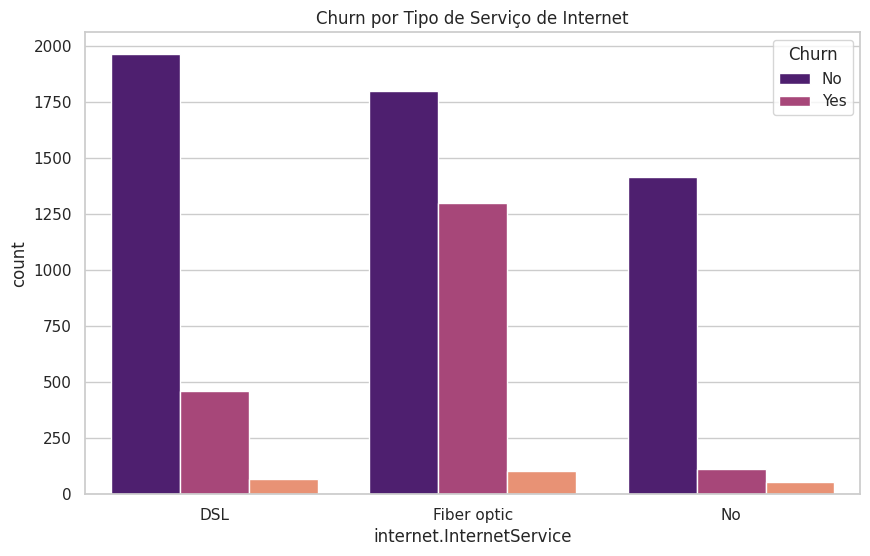

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='internet.InternetService', hue='Churn', palette='magma')
plt.title('Churn por Tipo de Serviço de Internet')
plt.show()

#🔧 Transformação

In [ ]:
colunas_chave = [
    'Churn',
    'customer.tenure',
    'internet.InternetService',
    'internet.TechSupport',
    'account.Contract',
    'account.PaymentMethod',
    'account.Charges.Monthly',
    'account.Charges.Total'
]

df_final = df[colunas_chave].copy()

print("📊 Correlação entre Tempo de Casa e Mensalidade:")
print(df_final[['customer.tenure', 'account.Charges.Monthly']].corr())

📊 Correlação entre Tempo de Casa e Mensalidade:
                         customer.tenure  account.Charges.Monthly
customer.tenure                 1.000000                 0.247982
account.Charges.Monthly         0.247982                 1.000000


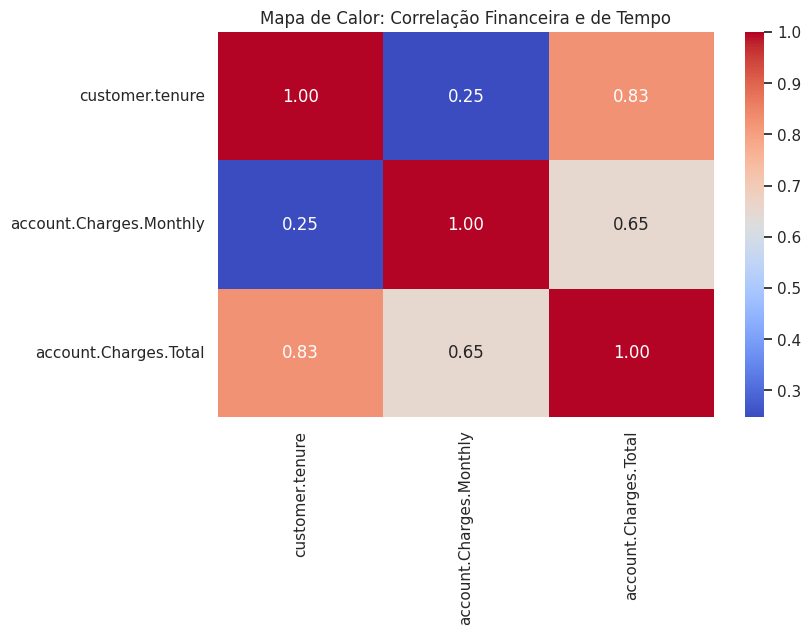

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_final['account.Charges.Total'] = pd.to_numeric(df_final['account.Charges.Total'], errors='coerce').fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(df_final[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlação Financeira e de Tempo')
plt.show()

In [ ]:
print("❓ Valores ausentes por coluna:")
print(df_final.isnull().sum())

print(f"\n👯 Total de linhas duplicadas: {df_final.duplicated().sum()}")

colunas_categoricas = df_final.select_dtypes(include=['object']).columns

print("\n🔍 Valores únicos por categoria:")
for col in colunas_categoricas:
    print(f"{col}: {df_final[col].unique()}")

❓ Valores ausentes por coluna:
Churn                       0
customer.tenure             0
internet.InternetService    0
internet.TechSupport        0
account.Contract            0
account.PaymentMethod       0
account.Charges.Monthly     0
account.Charges.Total       0
dtype: int64

👯 Total de linhas duplicadas: 111

🔍 Valores únicos por categoria:
Churn: ['No' 'Yes' '']
internet.InternetService: ['DSL' 'Fiber optic' 'No']
internet.TechSupport: ['Yes' 'No' 'No internet service']
account.Contract: ['One year' 'Month-to-month' 'Two year']
account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [ ]:
import numpy as np

df_final = df_final.replace(r'^\s*$', np.nan, regex=True)

df_final['account.Charges.Total'] = pd.to_numeric(df_final['account.Charges.Total'], errors='coerce').fillna(0)

cols_to_fix = ['internet.TechSupport']
for col in cols_to_fix:
    df_final[col] = df_final[col].replace('No internet service', 'No')

df_final['customer.tenure'] = df_final['customer.tenure'].astype(int)
df_final['account.Charges.Monthly'] = df_final['account.Charges.Monthly'].astype(float)

print("✅ Limpeza concluída!")
print(f"Valores nulos restantes:\n{df_final.isnull().sum()}")

✅ Limpeza concluída!
Valores nulos restantes:
Churn                       224
customer.tenure               0
internet.InternetService      0
internet.TechSupport          0
account.Contract              0
account.PaymentMethod         0
account.Charges.Monthly       0
account.Charges.Total         0
dtype: int64


In [ ]:
analise_churn = df_final.groupby('Churn').agg({
    'customer.tenure': 'mean',
    'account.Charges.Monthly': 'mean',
    'account.Charges.Total': 'mean'
}).round(2)

print("\n📈 Perfil Médio: Churn vs. Retenção")
print(analise_churn)


📈 Perfil Médio: Churn vs. Retenção
       customer.tenure  account.Charges.Monthly  account.Charges.Total
Churn                                                                 
No               37.57                    61.27                2549.91
Yes              17.98                    74.44                1531.80


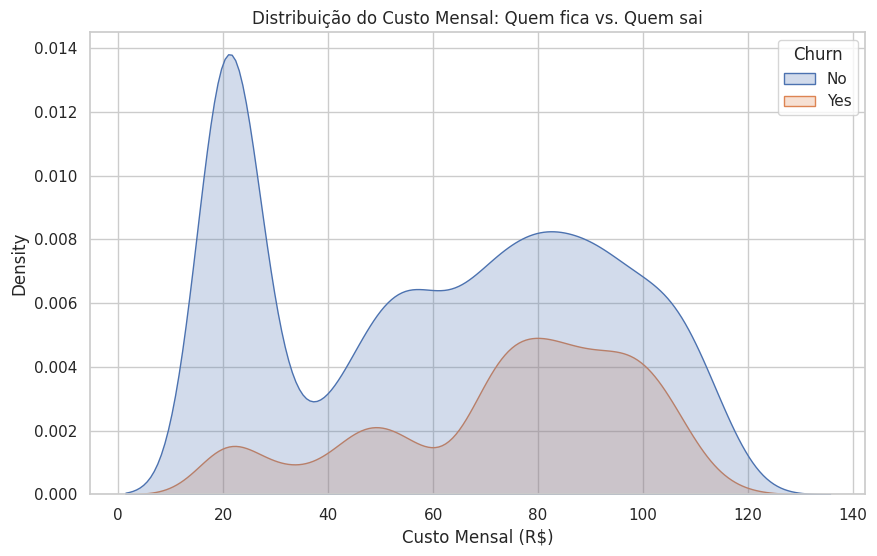

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='account.Charges.Monthly', hue='Churn', fill=True)
plt.title('Distribuição do Custo Mensal: Quem fica vs. Quem sai')
plt.xlabel('Custo Mensal (R$)')
plt.show()

In [ ]:
tradução_colunas = {
    'Churn': 'Evasao',
    'customer.tenure': 'Meses_Contrato',
    'internet.InternetService': 'Tipo_Internet',
    'internet.TechSupport': 'Suporte_Tecnico',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Valor_Mensal',
    'account.Charges.Total': 'Valor_Total',
    'account.Charges.Daily': 'Valor_Diario'
}

df_final.rename(columns=tradução_colunas, inplace=True)

df_final['Evasao_Binario'] = df_final['Evasao'].map({'Yes': 1, 'No': 0})

df_final['Tipo_Contrato'] = df_final['Tipo_Contrato'].replace({
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
})

print("✅ Dados padronizados e traduzidos para o relatório final!")
display(df_final.head())

✅ Dados padronizados e traduzidos para o relatório final!


,Evasao,Meses_Contrato,Tipo_Internet,Suporte_Tecnico,Tipo_Contrato,Metodo_Pagamento,Valor_Mensal,Valor_Total,Evasao_Binario
0,No,9,DSL,Yes,Anual,Mailed check,65.6,593.30,0.0
1,No,9,DSL,No,Mensal,Mailed check,59.9,542.40,0.0
2,Yes,4,Fiber optic,No,Mensal,Electronic check,73.9,280.85,1.0
3,Yes,13,Fiber optic,No,Mensal,Electronic check,98.0,1237.85,1.0
4,Yes,3,Fiber optic,Yes,Mensal,Mailed check,83.9,267.40,1.0


#📊 Carga e análise

In [ ]:
estatistica_numerica = df_final[['Meses_Contrato', 'Valor_Mensal', 'Valor_Total']].describe().T

estatistica_numerica['median'] = df_final[['Meses_Contrato', 'Valor_Mensal', 'Valor_Total']].median()

print("📊 Resumo Estatístico das Variáveis Numéricas:")
display(estatistica_numerica[['mean', 'median', 'std', 'min', 'max']])

print("\n🔍 Resumo das Variáveis Categóricas:")
display(df_final.describe(include=['object']).T)

📊 Resumo Estatístico das Variáveis Numéricas:


,mean,median,std,min,max
Meses_Contrato,32.346498,29.0,24.571773,0.00,72.00
Valor_Mensal,64.720098,70.3,30.129572,18.25,118.75
Valor_Total,2277.182035,1389.2,2268.648587,0.00,8684.80



🔍 Resumo das Variáveis Categóricas:


,count,unique,top,freq
Evasao,7043,2,No,5174
Tipo_Internet,7267,3,Fiber optic,3198
Suporte_Tecnico,7267,2,No,5163
Tipo_Contrato,7267,3,Mensal,4005
Metodo_Pagamento,7267,4,Electronic check,2445


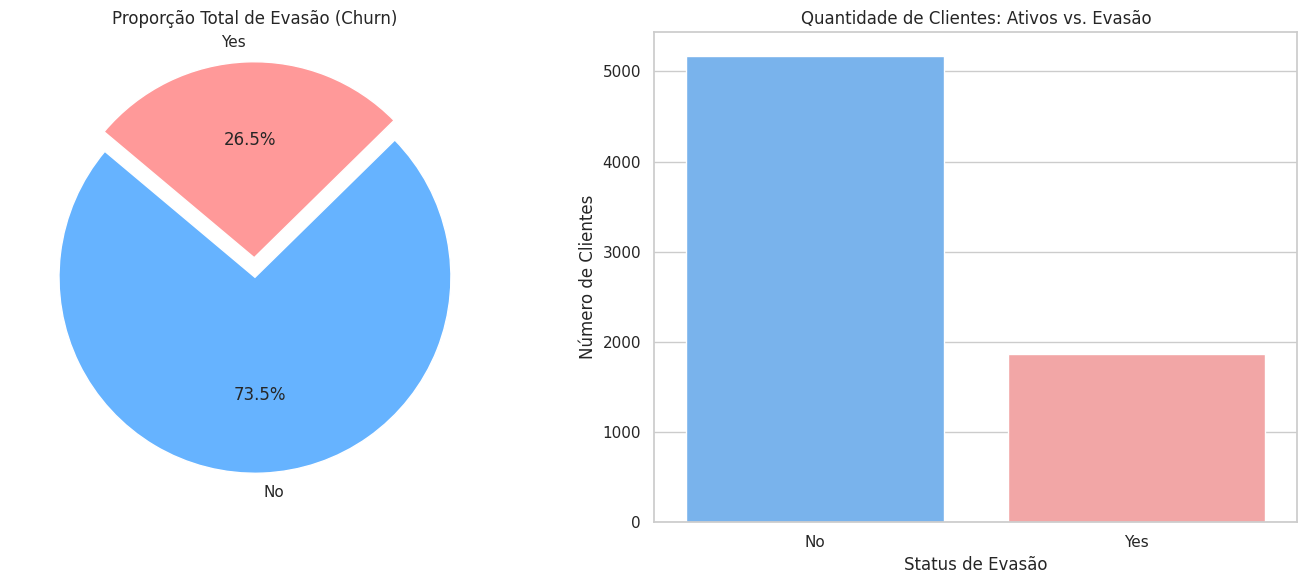

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Filtrando apenas 'No' e 'Yes' para garantir que o explode funcione corretamente
contagem_evasao = df_final[df_final['Evasao'].isin(['No', 'Yes'])]['Evasao'].value_counts()
plt.pie(contagem_evasao, labels=contagem_evasao.index, autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'], startangle=140, explode=(0, 0.1))
plt.title('Proporção Total de Evasão (Churn)')

plt.subplot(1, 2, 2)
# Filtering data for countplot to match the pie chart and avoid UserWarning
# Also applying FutureWarning recommendation by using hue and legend=False
sns.countplot(data=df_final[df_final['Evasao'].isin(['No', 'Yes'])], x='Evasao', hue='Evasao', legend=False, palette=['#66b3ff','#ff9999'])
plt.title('Quantidade de Clientes: Ativos vs. Evasão')
plt.ylabel('Número de Clientes')
plt.xlabel('Status de Evasão')

plt.tight_layout()
plt.show()

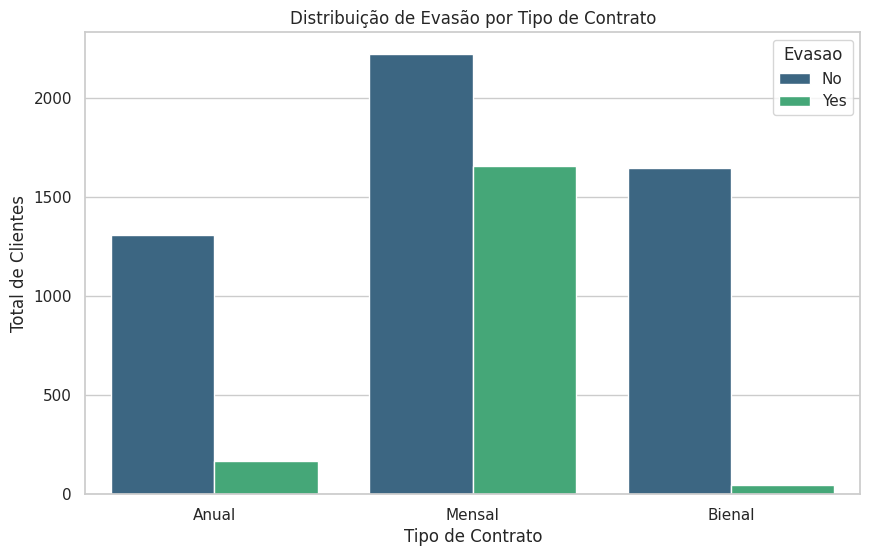

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='Tipo_Contrato', hue='Evasao', palette='viridis')
plt.title('Distribuição de Evasão por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Total de Clientes')
plt.show()

/tmp/ipykernel_446/1903261532.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='Evasao', y='Valor_Mensal', palette='magma')


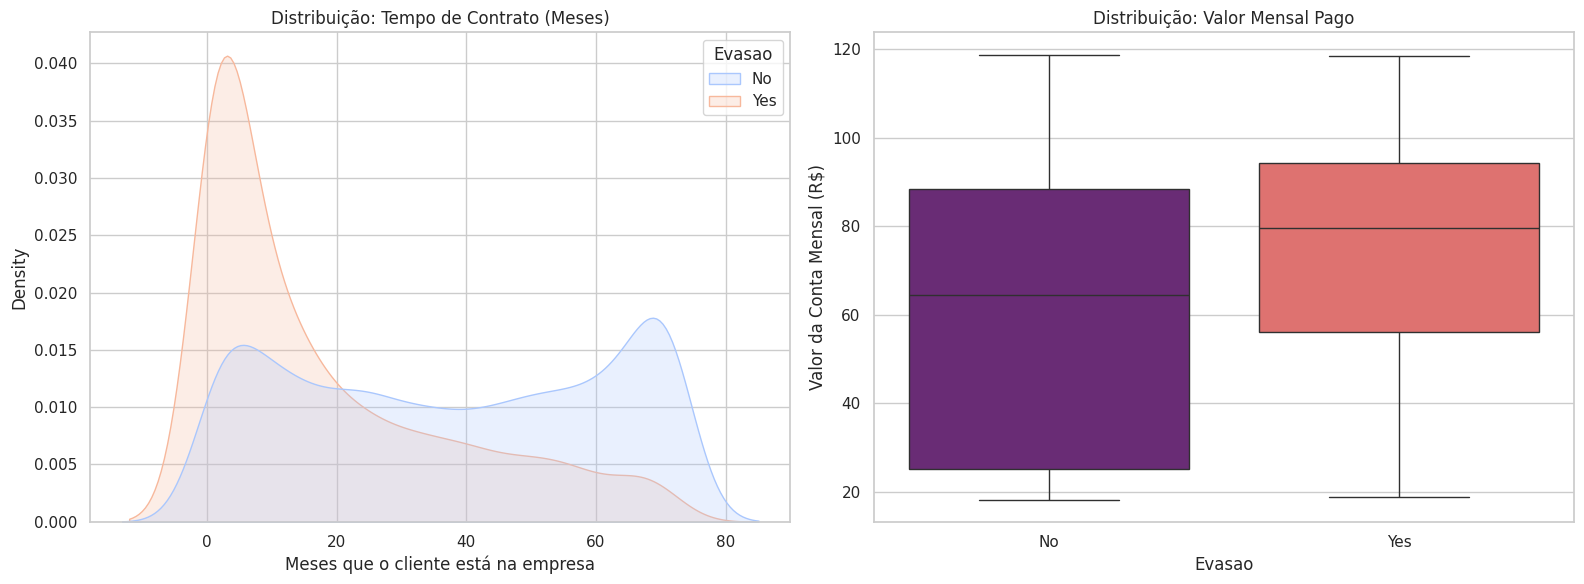

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df_final, x='Meses_Contrato', hue='Evasao', fill=True, common_norm=False, palette='coolwarm')
plt.title('Distribuição: Tempo de Contrato (Meses)')
plt.xlabel('Meses que o cliente está na empresa')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_final, x='Evasao', y='Valor_Mensal', palette='magma')
plt.title('Distribuição: Valor Mensal Pago')
plt.ylabel('Valor da Conta Mensal (R$)')

plt.tight_layout()
plt.show()

#📄Relatorio Final

In [ ]:
print(f"Taxa de Churn Analisada: {df_final['Evasao'].value_counts(normalize=True)[1]:.2%}")
print(f"Média de Valor Mensal (Churn): R$ {df_final[df_final['Evasao'] == 'Yes']['Valor_Mensal'].mean():.2f}")
print(f"Média de Valor Mensal (Retido): R$ {df_final[df_final['Evasao'] == 'No']['Valor_Mensal'].mean():.2f}")

Taxa de Churn Analisada: 26.54%
Média de Valor Mensal (Churn): R$ 74.44
Média de Valor Mensal (Retido): R$ 61.27


/tmp/ipykernel_446/1745962019.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Taxa de Churn Analisada: {df_final['Evasao'].value_counts(normalize=True)[1]:.2%}")
